# Lab 5: Decentralized RL

The lab covers LLM RL post-training in a centralized and decentralized setting.

## GRPO LLM RL Post-training

GRPO (Group Relative Policy Optimization) is an RL post-training technique used to scale test-time compute for extended reasoning.
It is particularly suited for solving complex, but verifiable tasks, such as mathematical problems.
Compared to prior techniques like PPO (Proximal Policy Optimization), which jointly train a value model (RL critic) alongside the policy model (RL actor), GRPO has the policy model generate multiple responses and calculates the value of each relative to the average.
By removing the policy model, GRPO drastically reduces memory and computational overhead.

Comparison of PPO and GRPO:
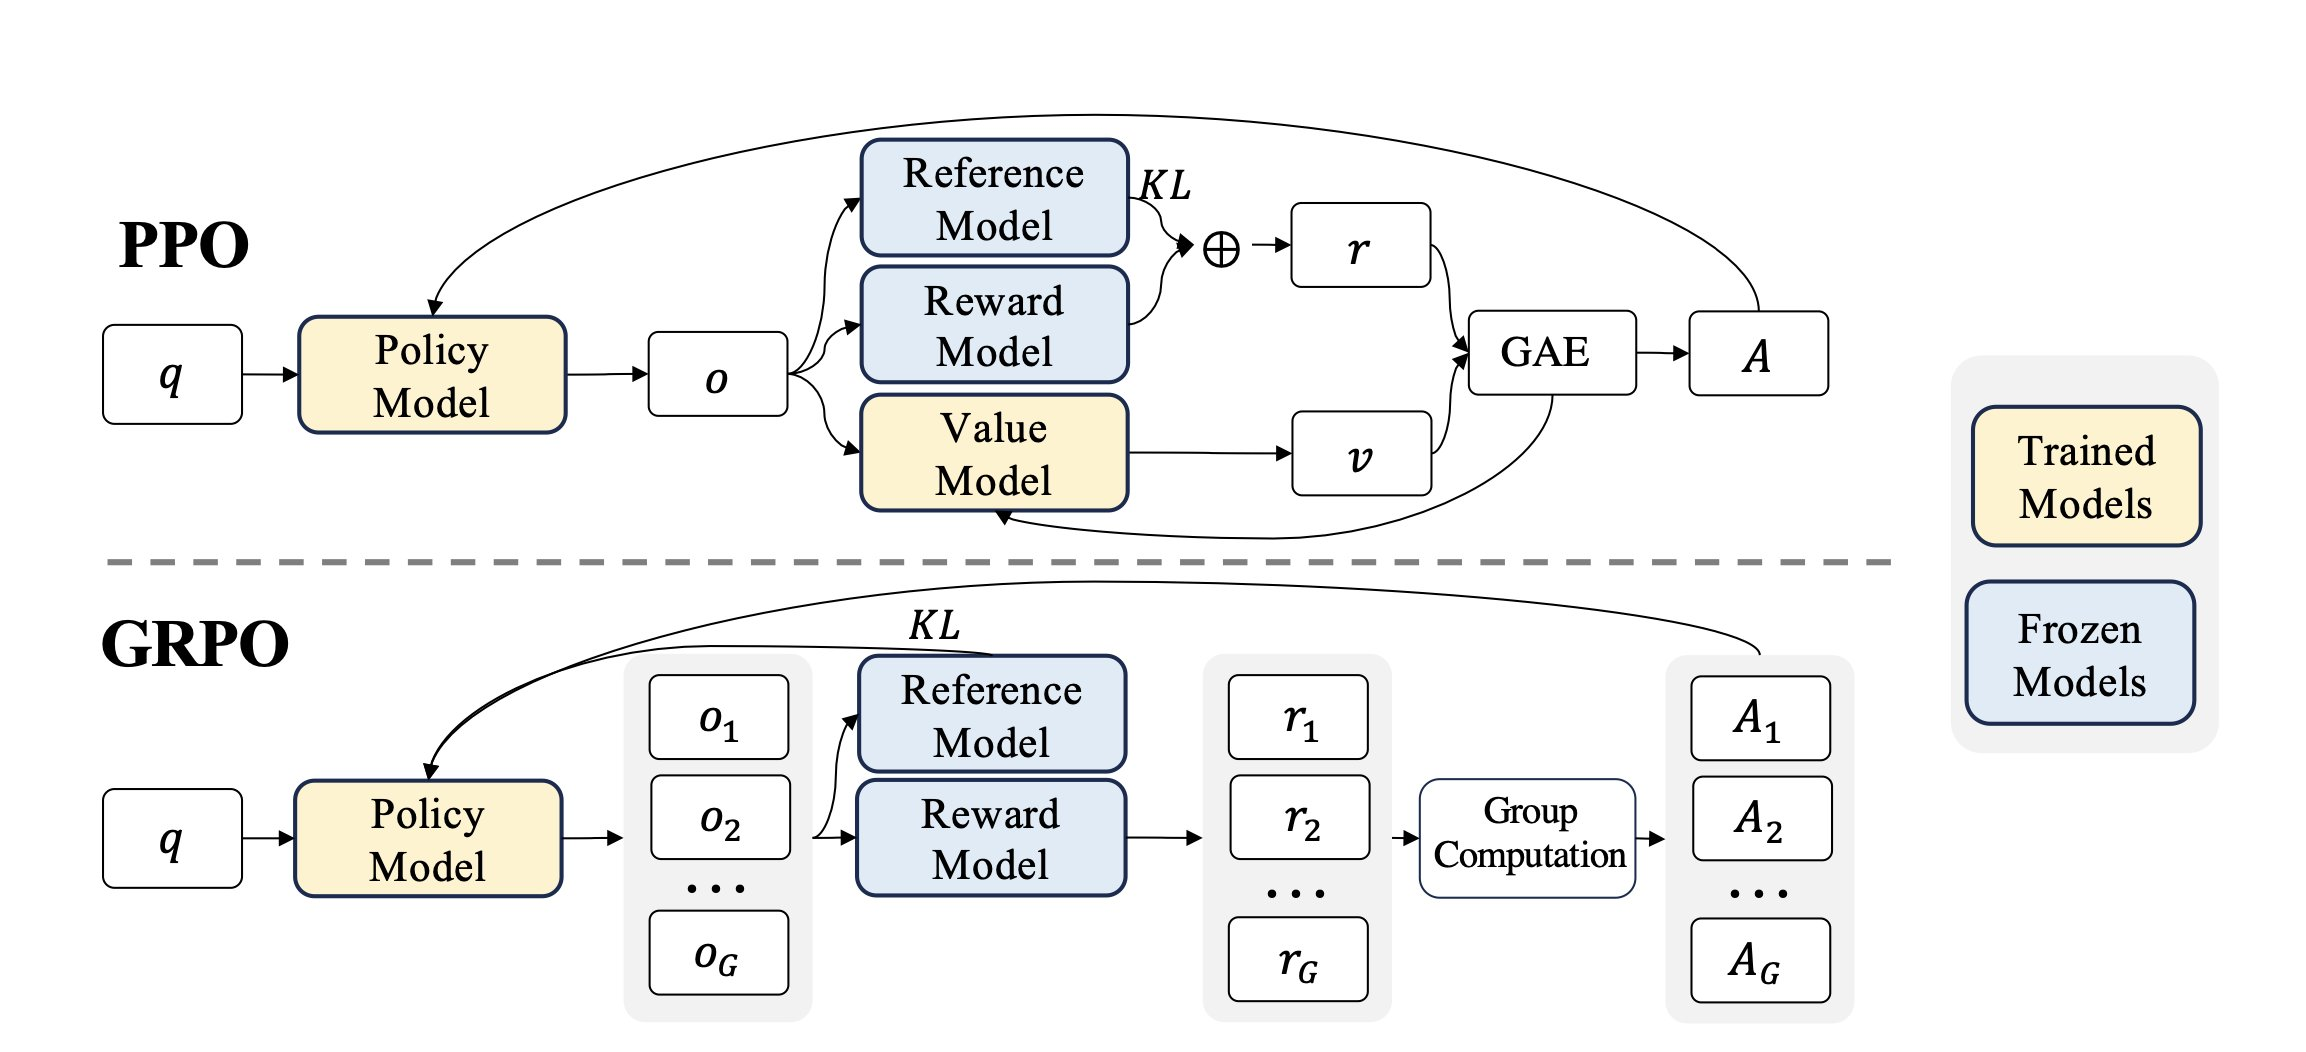

Overview of GRPO's loss:

<a href="https://huggingface.co/learn/cookbook/fine_tuning_llm_grpo_trl" target="_blank"><img src="https://huggingface.co/datasets/trl-lib/documentation-images/resolve/main/grpo_visual.png" alt="GRPO Loss Overview"></a>

While the lab focuses on GRPO, [further variations of the base technique exist]((https://huggingface.co/blog/NormalUhr/grpo-to-dapo-and-gspo)), such as DAPO and GSPO.

---

We use the [Qwen2.5-0.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct), since it is small and quite capable for its size.

In [ ]:
import torch
from commons.utils import get_device
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = get_device()
torch.set_float32_matmul_precision("high")

model_id = "Qwen/Qwen2.5-0.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(model_id, device_map=DEVICE)
tokenizer = AutoTokenizer.from_pretrained(model_id)

We use the [OpenAI GSM8K dataset](https://huggingface.co/datasets/openai/gsm8k), which contains middle school math problems solvable with basic arithmetic operations.

In [ ]:
import json

import torch
from datasets import Dataset, load_dataset

# https://huggingface.co/blog/prithivMLmods/smollm-grpo-ft

SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
...
</reasoning>
<answer>
...
</answer>
"""


def extract_xml_answer(text: str) -> str:
    answer = text.split("<answer>")[-1]
    answer = answer.split("</answer>")[0]

    return answer.strip()


def extract_hash_answer(text: str) -> str | None:
    if "####" not in text:
        return None

    return text.split("####")[1].strip()


def get_dataset(split: str, tok, max_nr_tokens: int) -> Dataset:
    data = load_dataset("openai/gsm8k", "main", split=split)
    print("Original dataset sample:")
    print(json.dumps(data[0], indent=2))
    data = data.map(
        lambda x: {
            "prompt": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": x["question"]},
            ],
            "answer": extract_hash_answer(x["answer"]),
        }
    )
    data = data.remove_columns("question")
    data = data.filter(
        lambda x:
        len(tok.apply_chat_template(
            x["prompt"],
            tokenize=True,
            add_generation_prompt=True
        )) <= max_nr_tokens,
        num_proc=4
    )
    print("Preprocessed dataset sample:")
    print(json.dumps(data[0], indent=2))

    return data


TRAIN_DATASET = get_dataset(
    "train[:20%]", tokenizer, 128)

Reward function definitions:

In [ ]:
import re


# compare the extracted answer from the response with the known answer
def correctness_reward_func(completions, answer, **kwargs) -> list[float]:
    responses = [completion[0]["content"] for completion in completions]
    extracted_responses = [extract_xml_answer(r) for r in responses]

    # q = prompts[0][-1]["content"]
    # print(
    #     "-" * 20,
    #     f"Question:\n{q}",
    #     f"\nAnswer:\n{answer[0]}",
    #     f"\nResponse:\n{responses[0]}",
    #     f"\nExtracted:\n{extracted_responses[0]}",
    # )

    return [2.0 if r.strip() == a.strip() else 0.0 for r, a in zip(extracted_responses, answer)]


# check if the answer is an integer
def int_reward_func(completions, **kwargs) -> list[float]:
    responses = [completion[0]["content"] for completion in completions]
    extracted_responses = [extract_xml_answer(r) for r in responses]

    return [0.5 if r.isdigit() else 0.0 for r in extracted_responses]


STRICT_PATTERN = re.compile(
    r"\n<reasoning>\n.*?\n</reasoning>\n<answer>\n.*?\n</answer>\n$",
    re.DOTALL)

# check if the completion follows the strict format
def strict_format_reward_func(completions, **kwargs) -> list[float]:
    return [
        0.5 if STRICT_PATTERN.match(comp[0]["content"]) else 0.0
        for comp in completions]


SOFT_PATTERN = re.compile(
    r"<reasoning>.*?</reasoning>\s*<answer>.*?</answer>",
    re.DOTALL)

# check if the completion follows a more relaxed format
def soft_format_reward_func(completions, **kwargs) -> list[float]:
    return [
        0.5 if SOFT_PATTERN.match(comp[0]["content"]) else 0.0
        for comp in completions]


# count XML tags and penalizes extra content
def count_xml(text) -> float:
    count = 0.0

    if text.count("<reasoning>\n") == 1:
        count += 0.125
    if text.count("\n</reasoning>\n") == 1:
        count += 0.125
    if text.count("\n<answer>\n") == 1:
        count += 0.125
        count -= len(text.split("\n</answer>\n")[-1]) * 0.001
    if text.count("\n</answer>") == 1:
        count += 0.125
        count -= (len(text.split("\n</answer>")[-1]) - 1) * 0.001

    return count


def xmlcount_reward_func(completions, **kwargs) -> list[float]:
    contents = [completion[0]["content"] for completion in completions]

    return [count_xml(c) for c in contents]

Utility function for running the model on a given prompt:

In [ ]:
def generate_with_reasoning(
      mod, tok, prompt: list[dict[str, str]]) -> tuple[str, int]:
    # build and tokenizethe prompt from the dataset
    # then move input to the model's device
    inputs = tok.apply_chat_template(
        prompt, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt"
    ).to(mod.device)

    # generate text without gradients
    with torch.no_grad():
        output_ids = mod.generate(**inputs, max_new_tokens=1024)

    # get number of generated tokens
    num_input_tokens = inputs["input_ids"].size(1)
    num_generated_tokens = output_ids.size(1) - num_input_tokens

    # decode and extract model response
    generated_text = tok.decode(
        # slice skips original prompt tokens
        output_ids[0][num_input_tokens:],
        skip_special_tokens=True)

    return generated_text, num_generated_tokens

In [ ]:
generate_with_reasoning(model, tokenizer, TRAIN_DATASET[0]["prompt"])

We perform a form of parameter-efficient fine-tuning via [LoRA](https://arxiv.org/pdf/2106.09685), which allows us to optimize a much smaller portion of the weights compared to full fine-tuning:

In the overview below, only `A` and `B` are optimized:

<a href="https://unsloth.ai/docs/get-started/fine-tuning-llms-guide" target="_blank">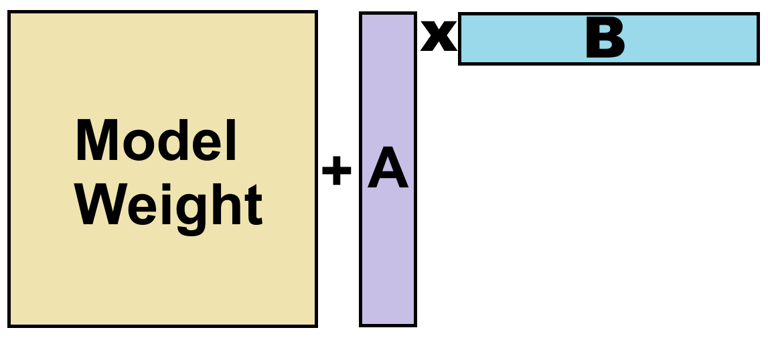</a>

The dot product of the fine-tuning matrices is added directly to the main model weights, so the fine-tuned model has the same number of parameters as the original one.

In [ ]:
from typing import cast

from peft import LoraConfig, PeftModel
from trl.trainer.grpo_config import GRPOConfig
from trl.trainer.grpo_trainer import GRPOTrainer, RewardFunc

# for single-GPU training
# the number of prompts in each step =
# per_device_train_batch_size / num_generations
grpo_config = GRPOConfig(
    output_dir="./outputs",
    per_device_train_batch_size=8,
    learning_rate=5e-6,
    weight_decay=0.1,
    adam_beta1=0.9,
    adam_beta2=0.99,
    max_grad_norm=0.1,
    num_train_epochs=1,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    log_on_each_node=False,
    logging_steps=50,
    save_steps=50,
    run_name="grpo_centralized",
    # number of completions per prompt
    num_generations=4,
    # max tokens for the new response part
    max_completion_length=384,
    use_vllm=True,
    vllm_mode="colocate",
    vllm_max_model_length=512,
)

lora_config = LoraConfig(
    # rank (higher = more parameters to tune)
    r=16,
    target_modules="all-linear",
    # lora strength
    lora_alpha=64,
    lora_dropout=0.05,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs= cast(
        list[RewardFunc],
        [
            xmlcount_reward_func,
            soft_format_reward_func,
            strict_format_reward_func,
            int_reward_func,
            correctness_reward_func
        ]
    ),
    args=grpo_config,
    train_dataset=TRAIN_DATASET,
    # use LoRA
    peft_config=lora_config,
)
trainer.model = torch.compile(trainer.model, dynamic=True)
cast(PeftModel, trainer.model).print_trainable_parameters()

In [ ]:
from peft import LoraModel

trainer.train()
model = cast(LoraModel, trainer.model).merge_and_unload().eval()
tokenizer = trainer.processing_class

In [ ]:
generate_with_reasoning(model, tokenizer, TRAIN_DATASET[0]["prompt"])

## Decentralized GRPO

See [vertical_drl.py](vertical_drl.py) for an implementation of the vertical decentralized RL mentioned in the lecture.
The [base.py](base.py) script contains a small manual implementation of base fine-tuning logic (without LoRA) and distributed communication primitives.